In [4]:
import r2l
import torch
import rl_utils
import gymnasium as gym
import random
import numpy  as np
import matplotlib.pyplot as plt

In [2]:
actor_lr = 5e-4
critic_lr = 5e-3
num_eisodes = 200
hidden_dim = 64
gamma = 0.98
tau = 0.005
buffer_size = 10000
minimal_size = 1000
batch_size = 64
sigma = 0.01
device = r2l.get_gpu()


In [3]:
env_name = 'Pendulum-v1'
env = gym.make(env_name)
env.reset(seed=1)
torch.manual_seed(0)
random.seed(0)
np.random.seed(1)
replay_buffer = r2l.ReplayBuffer(buffer_size)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
action_bound = env.action_space.high[0]
agent = r2l.DDPG(state_dim, action_dim, state_dim+action_dim, hidden_dim, False, action_bound, sigma, actor_lr, critic_lr, tau, gamma, device)

return_list = rl_utils.train_off_policy_agent(env, agent, num_eisodes, replay_buffer, minimal_size, batch_size)


Iteration 0:   0%|          | 0/20 [00:00<?, ?it/s]/home/austin/workspace/d2l/src/r2l.py:1681: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  torch.tensor(transition_dict["actions"], dtype=torch.float)
Iteration 9: 100%|██████████| 20/20 [00:06<00:00,  3.10it/s, episode=200, return=-140.045]


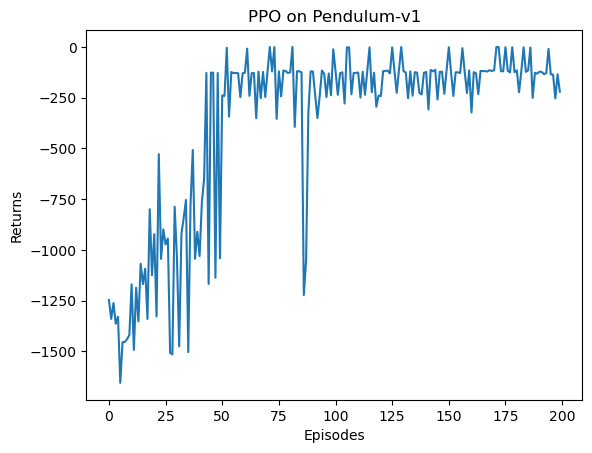

In [5]:
episode_list = list(range(len(return_list)))
plt.plot(episode_list, return_list)
plt.xlabel("Episodes")
plt.ylabel("Returns")
plt.title("PPO on {}".format(env_name))
plt.show()

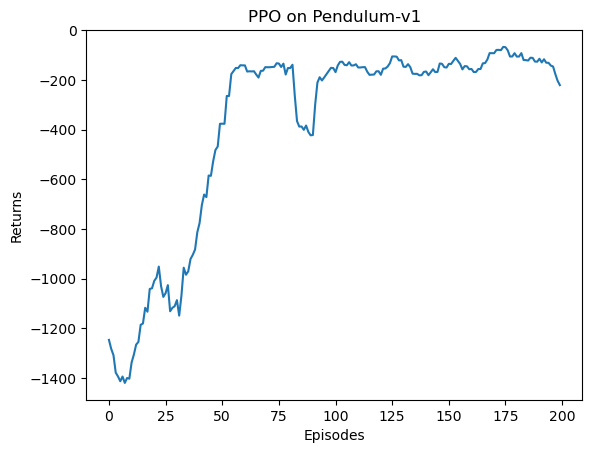

In [6]:
moving_return = rl_utils.moving_average(return_list, 9)
plt.plot(episode_list, moving_return)
plt.xlabel("Episodes")
plt.ylabel("Returns")
plt.title("PPO on {}".format(env_name))
plt.show()